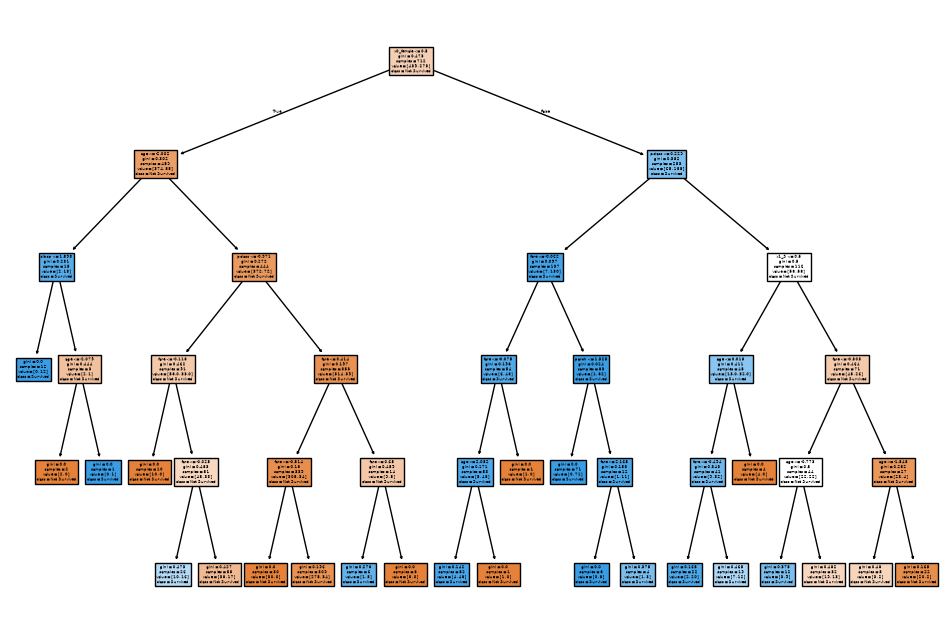

SMOTE F1: 0.7605633802816901
Best params: {'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 100}
OOB score: 0.8188202247191011
MAE: 20.809397730838697 RMSE: 30.473145462848713 R2: 0.3998999484440189 Adj R2: 0.3679419575327536


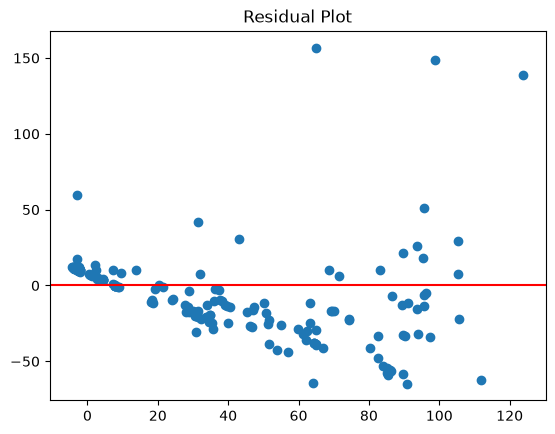

Pipeline saved.


In [5]:
# Cell 1: Imports
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
import joblib
import matplotlib.pyplot as plt

# Cell 2: Load cleaned dataset
df = pd.read_csv("titanic.csv")

# Cell 3: Train/test split (stratified)
X = df[["pclass","sex","age","sibsp","parch","fare","embarked"]]
y = df["survived"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

# Cell 4: Preprocessing pipeline
numeric_features = ["age","fare","sibsp","parch","pclass"]
categorical_features = ["sex","embarked"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

# Cell 5: Train classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
}

results = {}
for name, model in models.items():
    clf = Pipeline(steps=[("preprocessor", preprocessor),("classifier", model)])
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    results[name] = {
        "confusion": confusion_matrix(y_test,y_pred),
        "accuracy": accuracy_score(y_test,y_pred),
        "precision": precision_score(y_test,y_pred),
        "recall": recall_score(y_test,y_pred),
        "f1": f1_score(y_test,y_pred),
        "auc": roc_auc_score(y_test,clf.predict_proba(X_test)[:,1])
    }

# Cell 6: Visualize Decision Tree
dt_model = models["Decision Tree"]
dt_model.fit(preprocessor.fit_transform(X_train), y_train)
plt.figure(figsize=(12,8))
plot_tree(dt_model, feature_names=numeric_features+list(preprocessor.named_transformers_["cat"].named_steps["encoder"].get_feature_names_out()), class_names=["Not Survived","Survived"], filled=True)
plt.show()

# Cell 7: Imbalance handling (SMOTE example)
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(preprocessor.fit_transform(X_train), y_train)
lr = LogisticRegression(max_iter=500)
lr.fit(X_res,y_res)
y_pred_smote = lr.predict(preprocessor.transform(X_test))
print("SMOTE F1:", f1_score(y_test,y_pred_smote))

# Cell 8: Hyperparameter tuning for Random Forest
param_grid = {
    "classifier__n_estimators":[100,200],
    "classifier__max_depth":[None,5,10],
    "classifier__max_features":["sqrt","log2"]
}
rf_pipeline = Pipeline(steps=[("preprocessor", preprocessor),("classifier", RandomForestClassifier(oob_score=True, random_state=42))])
grid = GridSearchCV(rf_pipeline, param_grid, cv=3, scoring="f1")
grid.fit(X_train,y_train)
print("Best params:", grid.best_params_)
print("OOB score:", grid.best_estimator_.named_steps["classifier"].oob_score_)

# Cell 9: Regression side-task (predict fare)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_reg = df[["pclass","sex","age","sibsp","parch","embarked"]]
y_reg = df["fare"]
has_target = y_reg.notna()
X_reg = X_reg.loc[has_target]
y_reg = y_reg.loc[has_target]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg,y_reg,test_size=0.2,random_state=42)

reg_numeric_features = ["pclass","age","sibsp","parch"]
reg_categorical_features = ["sex","embarked"]
reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), reg_numeric_features),
        ("cat", Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore"))]), reg_categorical_features)
    ]
)
reg = Pipeline(steps=[("preprocessor", reg_preprocessor), ("regressor", LinearRegression())])
reg.fit(X_train_r,y_train_r)
y_pred_r = reg.predict(X_test_r)

mae = mean_absolute_error(y_test_r,y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r,y_pred_r))
r2 = r2_score(y_test_r,y_pred_r)
n_reg_features = reg.named_steps["regressor"].n_features_in_
adj_r2 = 1 - (1-r2)*(len(y_test_r)-1)/(len(y_test_r)-n_reg_features-1)

print("MAE:",mae,"RMSE:",rmse,"R2:",r2,"Adj R2:",adj_r2)

# Residual plot
plt.scatter(y_pred_r, y_test_r - y_pred_r)
plt.axhline(0, color="red")
plt.title("Residual Plot")
plt.show()

# Cell 10: Save best pipeline
best_pipeline = grid.best_estimator_
joblib.dump(best_pipeline,"saved_pipeline.joblib")
print("Pipeline saved.")
